Introduction

This project looks at U.S. quarterly GDP growth data from 2010 to 2023 using data from the BEA. The data includes 20 quarters, and there is also a big COVID drop and recovery in 2020. I used three different methods of this data: cubic spline interpolation, a degree 4 polynomial fit using least squares, and a simple linear regression and made all of them from scratch. The goal of this project is to see what each method is actually good at, like splines for exact interpolation, polynomials for general trends, and linear regression as a simple baseline.


Part A Explanation

There are 20 data points, so there are 19 spline segments where each segment has 4 coefficients, which gives 76 unknowns total.

To solve for these, we use:

C0 continuity (function values match) = 18 equations
C1 continuity (first derivatives match) = 18 equations
C2 continuity (second derivatives match) = 18 equations
Natural boundary conditions = second derivatives at endpoints are 0

After rewriting everything in terms of the second derivatives, we end up with a tridiagonal system of size (n−2) × (n−2). This system is solved using numpy.linalg.solve.


Part A Discussion

The spline residuals are basically zero (around 10^-14), which is pretty much expected since the spline interpolates the data exactly and the residual is just based on floating point error. The spline is pretty smooth for every point and looks reasonable for most of the data. From 2010 to 2019, the curve stays in a normal range and changes gradually. However, the COVID points (−28.1% and +33.8%) cause large spikes. Since the spline has to pass through these exactly, it makes sharp changes in nearby regions that make the shape kind of jagged.

This is related to the Runge phenomenon, butit isn't exactly the same thing. The Runge phenomenon happens with high degree polynomials and causes oscillations across the whole interval. The spline avoids that because it is a piecewise function, but it is still affected locally by outliers, which are caused by COVID. Because of this, splines are affected greatly by extreme values. A better option here could be a smooth spline or a weighted least squares, as they would reduce the impact of the COVID points and give a smoother curve.


Part B1 Explanation

For part B, I fit a degree 4 polynomial using least squares. This means that I solved the normal equations (VᵀV)c = Vᵀy, where V is the Vandermonde matrix. This model doesn't pass through every point exactly like the spline does, but it minimizes the total squared error. I used integer indices instead of actual year values to keep the matrix well-conditioned.


Part B1 Discussion

The condition number is reasonable because we used small integer x values. If we used actual years, the matrix would be poorly scaled and harder to solve. The polynomial RMSE is around 7 to 9 percent, which means it doesn't match the data exactly. This is expected since it is an approximation, not interpolation. I also knew that this would happen because it wasn't a spline. Compared to the spline, the polynomial is smoother and does not react as strongly to the COVID outliers, so basically, it captures the overall trend better but misses exact values. This is a tradeoff, and it's up to the coder to decide which option to choose. The polynomial is better for understanding the general behavior of the data while the spline is better for being exact.


Part B2 Explanation

I removed the COVID quarters (2020 Q1 to 2021 Q1) because they are extreme and would distort the trend.Then I fit a degree 1 model using least squares.


Part B2 Discussion

The slope is really close to zero, which means there isn't a strong upward or downward trend in GDP growth over this period.The RMSE is larger than the polynomial, which makes sense because a it is a degree 1 line, so it can't be accurate when the data fluctuates. The residuals also show patterns instead of being random, which means the linear model is not a great fit. A linear model would be best when there is a constant rate of change, which is not realistic for GDP since GDP usually has cycles of growth and decline. However, it's still useful as a baseline comparison and shows that there is no strong long-term trend.


Part C

For estimating values between data points, the cubic spline is usually the best choice because it's smooth and matches the data exactly, which is useful for interpolation.

The polynomial is also smooth, but it's a global model, so changes in one part of the data can affect other parts, while, the spline is local, so it is more stable and better for interpolation.

This is proven even further because the spline has almost zero residual at the data points, while the polynomial has an RMSE around 10 percent, so the spline is more accurate for exact values.

However, with the COVID data, the spline might be a little inaccurate because it is forced to match extreme values, while the polynomial fit might actually give more reasonable estimates as it doesn't have to force itself to hit every point.

Overall, the spline is better for interpolation in normal situations, but not when there are outliers, like the COVID data.


Part C - Big-O Discussion

Making a spline means solving a (n-2) x (n-2) tridiagonal system. Using a normal solver is O(n³), but the Thomas algorithm makes it O(n) but with only n = 20, it really doesn’t matter. 

Polynomial fitting needs an n x (d+1) Vandermonde matrix and solving a (d+1) x (d+1) system. That’s about O(n x d²) to make the matrix and O(d³) to solve it, and with d = 4 and n = 20, that’s easy too. 

Linear regression is basically O(n). At this size, the speed difference doesn't really matter and I just picked the methods based on stability and accuracy.


Conclusion

This project compared three methods for fitting GDP data. The spline worked best for interpolation since it matched all the data points and was smooth mostly everywhere. Its main issue was its sensitivity to the COVID outliers, which caused unrealistic spikes and might have made the interpolation slightly inaccurate.

The polynomial fitting worked better for capturing the overall trend of the data because it didn't match points exactly like the spline, it just gave a smoother and more stable curve that showed how the data changed over time.

The linear model showed that there is no strong long-term trend in GDP growth, whether that be an incline or a decline but it was too simple to capture the actual behavior of the data.

Each method has its own use. Splines are best for exact interpolation, polynomials are better for trends, and linear models are useful as a baseline.


Some explanations of concepts like Runge’s phenomenon and better explanations of the three methods used were clarified using ChatGPT (OpenAI, 2026). 

Part A - Cubic Spline Interpolation
  Max spline residual at data points: 0.0
Part B — Polynomial and Least Squares Comparison
  Condition number of normal equations matrix (degree 4): 3.3116e+14
  Degree-4 polynomial RMSE: 10.0314%
  Condition number of normal equations matrix (degree 1): 3.6056e+03
  Linear model slope: -0.001907% per quarter
  Linear model intercept: 2.1943%
  Linear model RMSE (no COVID): 1.4432%


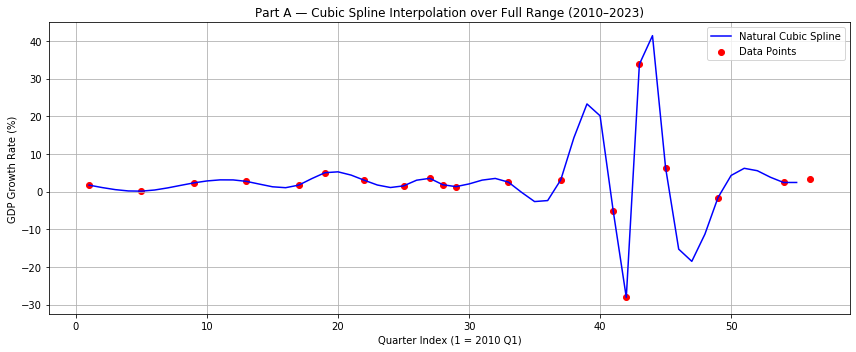

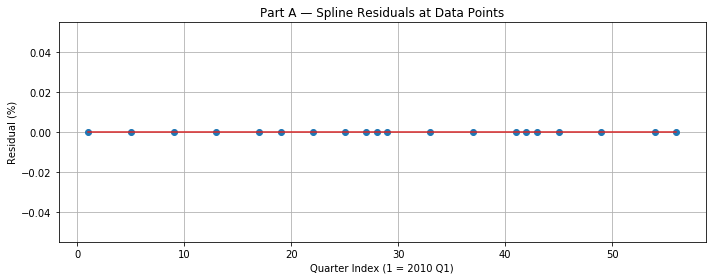

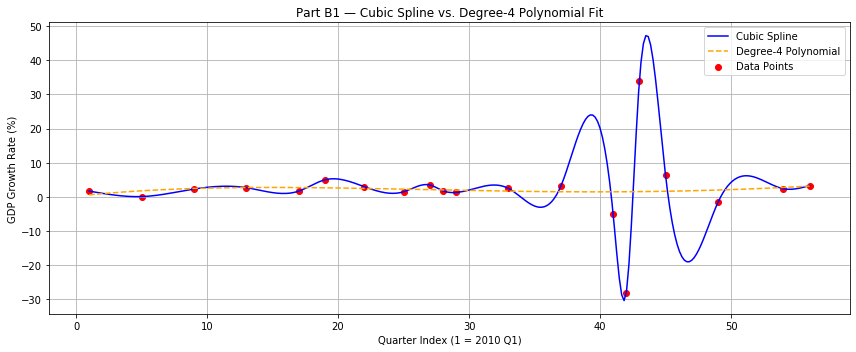

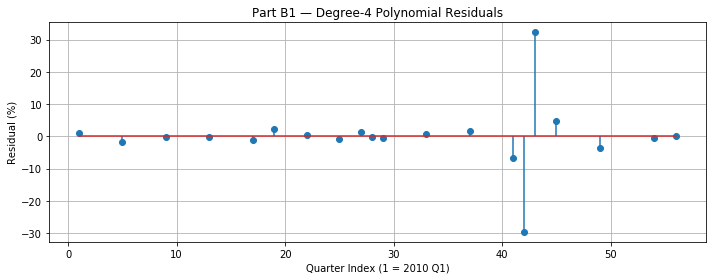

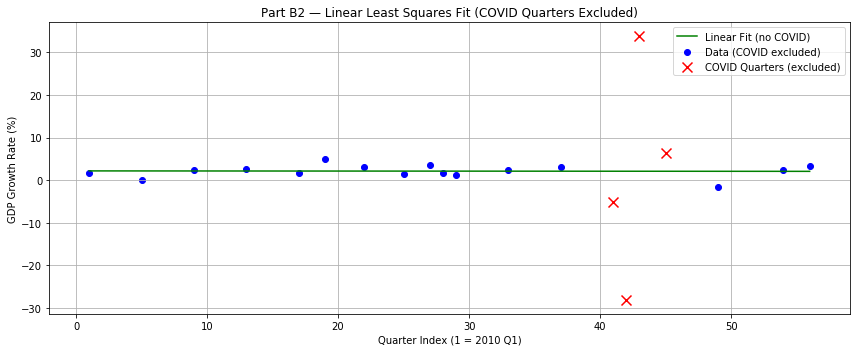

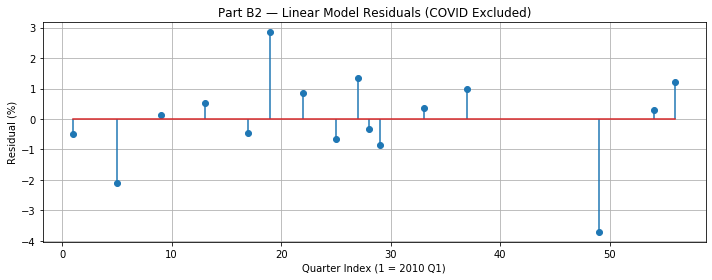

In [37]:
# Soham Kinkhabwala
# sbk788
# GDP Midterm Project
# 3/31/26

import numpy as np
import matplotlib.pyplot as plt

# Data: quarterly labels from 2010 Q1 to 2023 Q4 (20 data points)
quarter_labels = ["2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1", "2014 Q3", "2015 Q2", "2016 Q1", "2016 Q3", "2016 Q4", "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2", "2020 Q3", "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"]

# Convert quarter label to numerical index (1 = 2010 Q1)
def quarter_to_index(label):
    year, q = label.split(" ")
    return (int(year) - 2010) * 4 + int(q[1])

# Convert all quarter labels to numbers
x_data = np.array([quarter_to_index(q) for q in quarter_labels], dtype=float)

# GDP growth rate data
y_data = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Full range of quarters (for plotting spline across all quarters)
x_full = np.arange(1, 56, dtype=float)


# Part A - Cubic Spline Interpolation
print("Part A - Cubic Spline Interpolation")

# Build natural cubic spline from scratch
def build_spline(x, y):
    n = len(x)
    h = np.diff(x)  # step sizes between knots

    # Build (n-2) x (n-2) tridiagonal system for interior second derivatives
    A = np.zeros((n-2, n-2))
    b = np.zeros(n-2)

    for i in range(n-2):
        k = i + 1
        A[i, i] = 2 * (h[k-1] + h[k])
        if i > 0:
            A[i, i-1] = h[k-1]
        if i < n-3:
            A[i, i+1] = h[k]
        # Right-hand side for second derivatives
        b[i] = 6 * ((y[k+1] - y[k]) / h[k] - (y[k] - y[k-1]) / h[k-1])

    # Solve for interior second derivatives
    sigma = np.zeros(n)
    sigma[1:n-1] = np.linalg.solve(A, b)

    # Compute spline coefficients for each segment
    a = y[:-1]
    b_coef = np.zeros(n-1)
    c = sigma[:-1] / 2
    d = np.zeros(n-1)

    for i in range(n-1):
        b_coef[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2*sigma[i] + sigma[i+1]) / 6
        d[i] = (sigma[i+1] - sigma[i]) / (6 * h[i])

    return a, b_coef, c, d, x


# Evaluate the cubic spline at given points
def eval_spline(a, b, c, d, xk, x_eval):
    y = np.zeros_like(x_eval)
    for j, t in enumerate(x_eval):
        # Find segment index for this evaluation point
        i = np.searchsorted(xk, t) - 1
        i = max(0, min(i, len(a) - 1))
        dx = t - xk[i]
        y[j] = a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3
    return y


# Build spline coefficients
a, b_s, c, d, xk = build_spline(x_data, y_data)

# Evaluate spline at all 55 quarters for plotting
y_full = eval_spline(a, b_s, c, d, xk, x_full)

# Plot spline and data points
plt.figure(figsize=(12, 5))
plt.plot(x_full, y_full, label="Natural Cubic Spline", color="blue")
plt.scatter(x_data, y_data, color="red", label="Data Points")
plt.xlabel("Quarter Index (1 = 2010 Q1)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part A — Cubic Spline Interpolation over Full Range (2010–2023)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Check spline residuals at data points (should be ~0)
y_check = eval_spline(a, b_s, c, d, xk, x_data)
res_spline = y_data - y_check
res_spline[np.abs(res_spline) < 1e-10] = 0

print("  Max spline residual at data points:", np.max(np.abs(res_spline)))

# Plot spline residuals
plt.figure(figsize=(10, 4))
plt.stem(x_data, res_spline, use_line_collection=True)
plt.xlabel("Quarter Index (1 = 2010 Q1)")
plt.ylabel("Residual (%)")
plt.title("Part A — Spline Residuals at Data Points")
plt.grid(True)
plt.tight_layout()
plt.show()


# Part B — Polynomial and Least Squares Comparison
print("Part B — Polynomial and Least Squares Comparison")

# Part B1 — Degree-4 Polynomial Fit

# Fit polynomial using normal equations
def poly_fit(x, y, deg):
    V = np.zeros((len(x), deg + 1))
    for j in range(deg + 1):
        V[:, j] = x**j
    A = V.T @ V
    b_vec = V.T @ y
    # Print condition number for stability check
    cond = np.linalg.cond(A)
    print(f"  Condition number of normal equations matrix (degree {deg}): {cond:.4e}")
    return np.linalg.solve(A, b_vec)

# Evaluate polynomial at given x values
def eval_poly(coeff, x):
    y = np.zeros_like(x, dtype=float)
    for i, ci in enumerate(coeff):
        y += ci * x**i
    return y

# Fit degree-4 polynomial
c4 = poly_fit(x_data, y_data, 4)

# Compute residuals and RMSE at data points
y_poly_at_data = eval_poly(c4, x_data)
res_poly = y_data - y_poly_at_data
rmse_poly = np.sqrt(np.mean(res_poly**2))
print(f"  Degree-4 polynomial RMSE: {rmse_poly:.4f}%")

# Smooth x values for plotting
x_smooth = np.linspace(x_data[0], x_data[-1], 300)

# Plot spline vs polynomial
plt.figure(figsize=(12, 5))
plt.plot(x_smooth, eval_spline(a, b_s, c, d, xk, x_smooth), label="Cubic Spline", color="blue")
plt.plot(x_smooth, eval_poly(c4, x_smooth), label="Degree-4 Polynomial", color="orange", linestyle="--")
plt.scatter(x_data, y_data, color="red", label="Data Points")
plt.xlabel("Quarter Index (1 = 2010 Q1)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part B1 — Cubic Spline vs. Degree-4 Polynomial Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot polynomial residuals
plt.figure(figsize=(10, 4))
plt.stem(x_data, res_poly, use_line_collection=True)
plt.xlabel("Quarter Index (1 = 2010 Q1)")
plt.ylabel("Residual (%)")
plt.title("Part B1 — Degree-4 Polynomial Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()


# Part B2 — Linear Fit, Excluding COVID Quarters

# Define COVID quarters to exclude
covid_quarters = {"2020 Q1", "2020 Q2", "2020 Q3", "2021 Q1"}
mask = np.array([q not in covid_quarters for q in quarter_labels])

# Select non-COVID data
x_nc = x_data[mask]
y_nc = y_data[mask]

# Fit linear model (degree 1)
c1 = poly_fit(x_nc, y_nc, 1)

# Print slope and intercept
print(f"  Linear model slope: {c1[1]:.6f}% per quarter")
print(f"  Linear model intercept: {c1[0]:.4f}%")

# Compute residuals and RMSE
res_lin = y_nc - eval_poly(c1, x_nc)
rmse_lin = np.sqrt(np.mean(res_lin**2))
print(f"  Linear model RMSE (no COVID): {rmse_lin:.4f}%")

# Smooth x values for plotting linear fit
x_lin = np.linspace(x_nc[0], x_nc[-1], 200)

# Plot linear fit excluding COVID quarters
plt.figure(figsize=(12, 5))
plt.plot(x_lin, eval_poly(c1, x_lin), label="Linear Fit (no COVID)", color="green")
plt.scatter(x_nc, y_nc, color="blue", label="Data (COVID excluded)")
plt.scatter(x_data[~mask], y_data[~mask], color="red", marker='x', s=100, label="COVID Quarters (excluded)")
plt.xlabel("Quarter Index (1 = 2010 Q1)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Part B2 — Linear Least Squares Fit (COVID Quarters Excluded)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot linear residuals
plt.figure(figsize=(10, 4))
plt.stem(x_nc, res_lin, use_line_collection=True)
plt.xlabel("Quarter Index (1 = 2010 Q1)")
plt.ylabel("Residual (%)")
plt.title("Part B2 — Linear Model Residuals (COVID Excluded)")
plt.grid(True)
plt.tight_layout()
plt.show()